# kappa-bounded latent FT-NODE variants — analysis of a trained run

This notebook **plots**; it does not train. Point it at a run directory produced by

```bash
uv run ftnode-train experiments/duffing/kappa_quick.yaml     # ~5 min
uv run ftnode-train experiments/duffing/kappa_full.yaml      # hours; use nohup
```

and every figure below comes back in seconds. The companion notebook
[`pkg_kappa_variants.ipynb`](pkg_kappa_variants.ipynb) trains and plots in one pass
and is the better place to *read* the pipeline; this one is for iterating on figures
without paying for training each time.

Everything is keyed by variant **slug** (`l-ft-k-svd-clamp`), with display labels
pulled from the run for legends.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from ftnode.experiments import load_run
from ftnode.diagnostics import (A_stats, skew_stats, eigvals_A, eig_field_jac,
                                pca_2d, linear_recovery_r2, g_image)
from ftnode.plotting import band, seed_grid, stack_histories
from ftnode.systems import equilibria, sinks
from ftnode.train import rollout_y

# Relative to THIS notebook's folder, not the repo root -- a notebook's working
# directory is its own. Absolute paths work too.
RUN = '../../runs/kappa_quick'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
run = load_run(RUN)
print(run)
print('trained', run.meta.get('created'), 'on', run.meta['invocations'][-1]['device'])

<Run 'kappa_quick' at ../../runs/kappa_quick: 4 variants x 2 seeds>
trained 2026-08-05T21:48:17-06:00 on cuda


## What is in the run

In [2]:
spec       = run.spec
budget     = spec.budget
model_cfg  = spec.model
train_cfg  = spec.train
SLUGS      = run.slugs
LABEL      = run.names
SEEDS      = list(run.seeds)
FT_SLUGS   = [v.slug for v in run.variants if not v.is_baseline]
BOUNDED    = {v.slug for v in run.variants if v.operator in ('svd_clamp', 'youla')}

histories = run.histories
models    = run.models(device)
train, val = run.datasets(device)

r_in = model_cfg.equilibrium.R_g * np.sqrt(budget.m)
print(f'budget = c_P + c_K = {budget.budget:.3f}   c_P = {budget.c_P:.3f}   c_K = {budget.c_K:.3f}')
print(f'sigma_max = {budget.sigma_max:.3f}   kappa <= {budget.kappa_max}   l_bound = {budget.l_bound:.4f}')
print(f'r_in = R_g*sqrt(m) = {r_in:.3f}   ->   certified R = kappa_max*r_in = {budget.kappa_max*r_in:.1f}')
print('open-loop sinks at u=0:', sinks(0.0))
print()
for slug in SLUGS:
    got = sum(h is not None for h in histories[slug])
    best = [h['best_val'] for h in histories[slug] if h is not None]
    print(f'{LABEL[slug]:22s} {got}/{len(SEEDS)} seeds   '
          + (f'best_val {min(best):.3e} .. {max(best):.3e}' if best else '(none trained)'))

budget = c_P + c_K = 2.400   c_P = 0.960   c_K = 1.440
sigma_max = 2.500   kappa <= 25.0   l_bound = 0.3098
r_in = R_g*sqrt(m) = 4.000   ->   certified R = kappa_max*r_in = 100.0
open-loop sinks at u=0: {'left': array([-1.,  0.]), 'right': array([1., 0.])}

L-N                    2/2 seeds   best_val 7.067e-01 .. 7.103e-01
L-FT (unbounded)       2/2 seeds   best_val 7.398e-01 .. 7.482e-01
L-FT-k (SVD-clamp)     2/2 seeds   best_val 7.224e-01 .. 7.491e-01
L-FT-k (Youla)         2/2 seeds   best_val 7.000e-01 .. 8.153e-01


## Plot styling

A run stores *what was trained*, not how to draw it — so styling lives here, where
changing a color or a line style is a one-line notebook edit rather than a change
to `ftnode`. Add whatever `matplotlib` kwargs you want; `STYLE` is keyed by slug and
falls back to the default color cycle for a variant it does not name.

In [3]:
STYLE = {
    'l-n':              dict(color='C3', ls='--'),
    'l-ft-unbounded':   dict(color='C1'),
    'l-ft-k-svd-clamp': dict(color='C0'),
    'l-ft-k-youla':     dict(color='C2'),
}

def style(slug, **over):
    # matplotlib kwargs for a variant, with per-call overrides
    base = STYLE.get(slug, dict(color=f'C{SLUGS.index(slug) % 10}'))
    return {**base, **over}

COLOR = {s: style(s)['color'] for s in SLUGS}   # for the calls that want a color only
print({s: style(s) for s in SLUGS})

{'l-n': {'color': 'C3', 'ls': '--'}, 'l-ft-unbounded': {'color': 'C1'}, 'l-ft-k-svd-clamp': {'color': 'C0'}, 'l-ft-k-youla': {'color': 'C2'}}


## Precomputed validation rollouts

`ftnode-train` caches these into `rollouts.npz`, which is the one analysis step
expensive enough to be worth not repeating. The fallback recomputes them if the run
was made with `--no-rollouts`.

In [4]:
ROLL = run.rollouts()
if ROLL is None:
    print('no cache; rolling out now')
    ROLL = {}
    for slug in SLUGS:
        yh = np.full((len(SEEDS), val.W.shape[0], train_cfg.L_eval + 1), np.nan, np.float32)
        zz = np.full((len(SEEDS), val.W.shape[0], train_cfg.L_eval + 1, budget.m), np.nan, np.float32)
        for si, mdl in enumerate(models[slug]):
            if mdl is None:
                continue
            with torch.no_grad():
                yhat, zs = rollout_y(mdl.eval(), val.W, val.U, train_cfg.L_eval, train_cfg.h)
            y = yhat.cpu().numpy()
            yh[si] = np.where(np.isfinite(y), y, np.nan); zz[si] = zs.cpu().numpy()
        ROLL[slug] = {'yhat': yh, 'z': zz}

Yva_np  = val.Y.cpu().numpy()
tline_e = np.arange(train_cfg.L_eval + 1) * train_cfg.h
T_train = train_cfg.L * train_cfg.h
Zbox = ((2 * torch.rand(4000, budget.m, generator=torch.Generator().manual_seed(0)) - 1)
        * model_cfg.encoder.z_scale).to(device)
print('rollouts for', list(ROLL))

rollouts for ['l-n', 'l-ft-unbounded', 'l-ft-k-svd-clamp', 'l-ft-k-youla']


## D1 — training and extrapolation curves

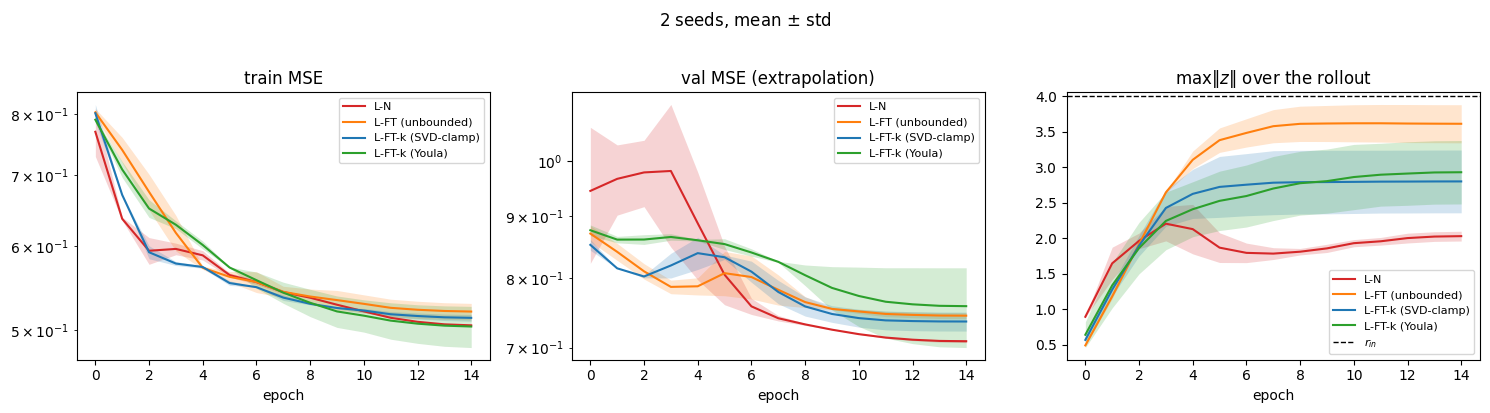

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for slug in SLUGS:
    for ax, key, logy in ((axes[0], 'train', True), (axes[1], 'val_extrap', True),
                          (axes[2], 'zmax', False)):
        band(ax, stack_histories(histories[slug], key, train_cfg.n_epochs),
             COLOR[slug], LABEL[slug], logy=logy)   # band takes a color; see STYLE
axes[0].set_title('train MSE')
axes[1].set_title('val MSE (extrapolation)')
axes[2].set_title(r'$\max\|z\|$ over the rollout')
axes[2].axhline(r_in, ls='--', c='k', lw=1, label=r'$r_{in}$')
for a in axes:
    a.set_xlabel('epoch'); a.legend(fontsize=8)
fig.suptitle(f'{len(SEEDS)} seeds, mean $\\pm$ std', y=1.02)
fig.tight_layout(); plt.show()

## D2 — best validation MSE by variant

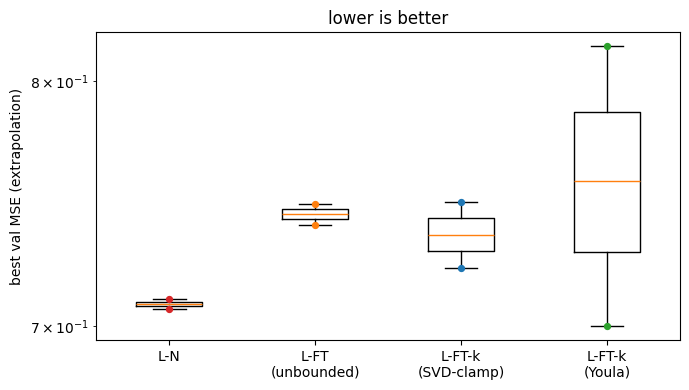

L-N                    median 7.085e-01   min 7.067e-01
L-FT (unbounded)       median 7.440e-01   min 7.398e-01
L-FT-k (SVD-clamp)     median 7.358e-01   min 7.224e-01
L-FT-k (Youla)         median 7.577e-01   min 7.000e-01


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
vals = [[h['best_val'] for h in histories[s] if h is not None] for s in SLUGS]
ax.boxplot(vals, tick_labels=[LABEL[s].replace(' ', '\n') for s in SLUGS], showfliers=False)
for i, (slug, vv) in enumerate(zip(SLUGS, vals), start=1):
    ax.scatter(np.full(len(vv), i), vv, color=COLOR[slug], zorder=3, s=18)
ax.set_yscale('log'); ax.set_ylabel('best val MSE (extrapolation)')
ax.set_title('lower is better'); fig.tight_layout(); plt.show()

for slug, vv in zip(SLUGS, vals):
    if vv:
        print(f'{LABEL[slug]:22s} median {np.median(vv):.3e}   min {min(vv):.3e}')

## K2 / K3 — the kappa bound on trained models

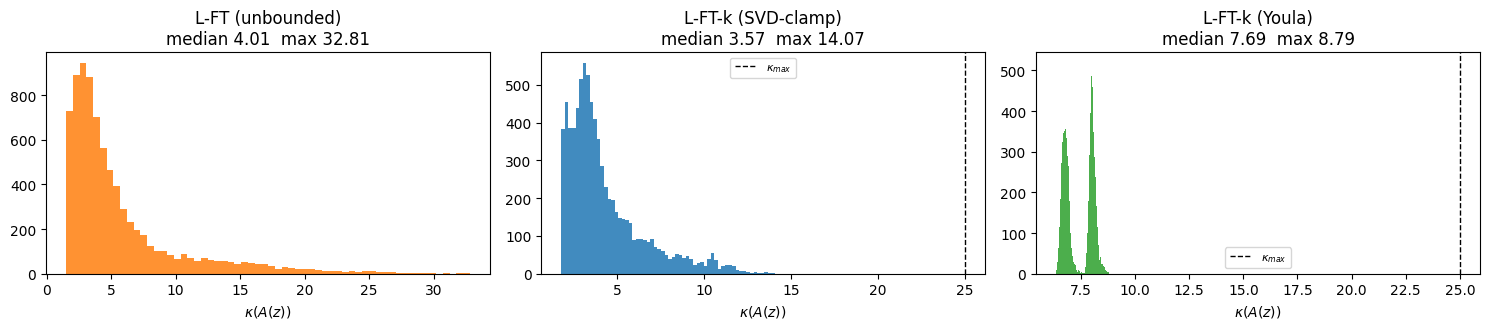

variant                   kappa med  kappa max   within bound
L-FT (unbounded)               4.01      32.81   --
L-FT-k (SVD-clamp)             3.57      14.07   True
L-FT-k (Youla)                 7.69       8.79   True


In [7]:
kappa_by_slug = {}
for slug in FT_SLUGS:
    ks = [A_stats(m.dynamics.eval(), Zbox)[2] for m in models[slug] if m is not None]
    kappa_by_slug[slug] = np.concatenate(ks) if ks else np.array([])

fig, axes = plt.subplots(1, len(FT_SLUGS), figsize=(5 * len(FT_SLUGS), 3.4), squeeze=False)
for ax, slug in zip(axes[0], FT_SLUGS):
    k = kappa_by_slug[slug]
    ax.hist(k, bins=60, color=COLOR[slug], alpha=.85)
    if slug in BOUNDED:
        ax.axvline(budget.kappa_max, ls='--', c='k', lw=1, label=r'$\kappa_{max}$')
        ax.legend(fontsize=8)
    ax.set_title(f'{LABEL[slug]}\nmedian {np.median(k):.2f}  max {k.max():.2f}')
    ax.set_xlabel(r'$\kappa(A(z))$')
fig.tight_layout(); plt.show()

print(f'{"variant":24s} {"kappa med":>10s} {"kappa max":>10s}   within bound')
for slug in FT_SLUGS:
    k = kappa_by_slug[slug]
    ok = '--' if slug not in BOUNDED else bool(k.max() <= budget.kappa_max + 1e-4)
    print(f'{LABEL[slug]:24s} {np.median(k):10.2f} {k.max():10.2f}   {ok}')

## K4 — skew diagnostics: `||K||_2` against its budget `c_K`

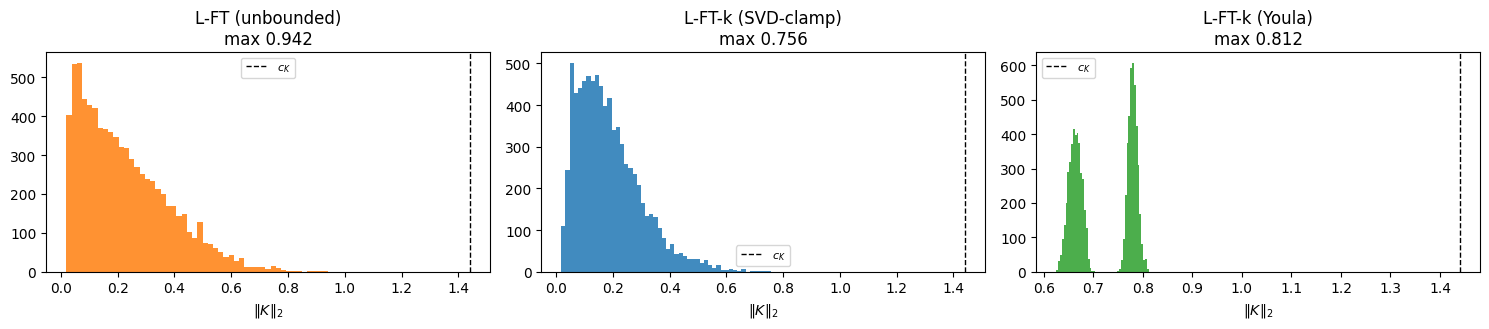

In [8]:
fig, axes = plt.subplots(1, len(FT_SLUGS), figsize=(5 * len(FT_SLUGS), 3.4), squeeze=False)
for ax, slug in zip(axes[0], FT_SLUGS):
    kn = np.concatenate([skew_stats(m.dynamics.eval(), Zbox)[0]
                         for m in models[slug] if m is not None])
    ax.hist(kn, bins=50, color=COLOR[slug], alpha=.85)
    ax.axvline(budget.c_K, ls='--', c='k', lw=1, label=r'$c_K$')
    ax.set_title(f'{LABEL[slug]}\nmax {kn.max():.3f}'); ax.set_xlabel(r'$\|K\|_2$')
    ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## K5 — forward invariance

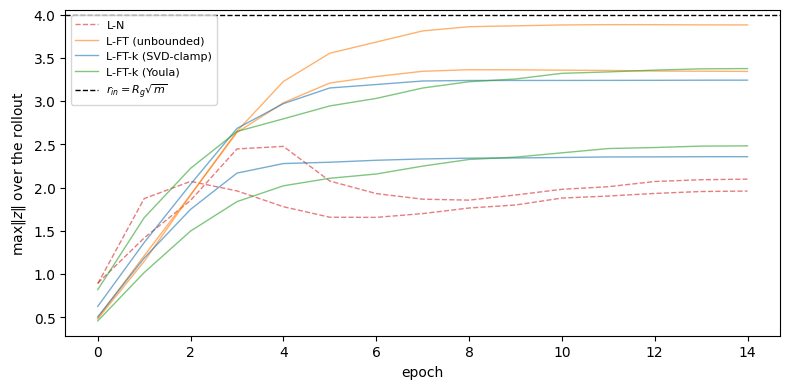

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
for slug in SLUGS:
    for si, h in enumerate(histories[slug]):
        if h is None or not h['zmax']:
            continue
        ax.plot(h['zmax'], alpha=.6, lw=1,
                label=LABEL[slug] if si == 0 else None, **style(slug))
ax.axhline(r_in, ls='--', c='k', lw=1, label=r'$r_{in}=R_g\sqrt{m}$')
ax.set_xlabel('epoch'); ax.set_ylabel(r'$\max\|z\|$ over the rollout')
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## D3 — reconstruction on a held-out trajectory

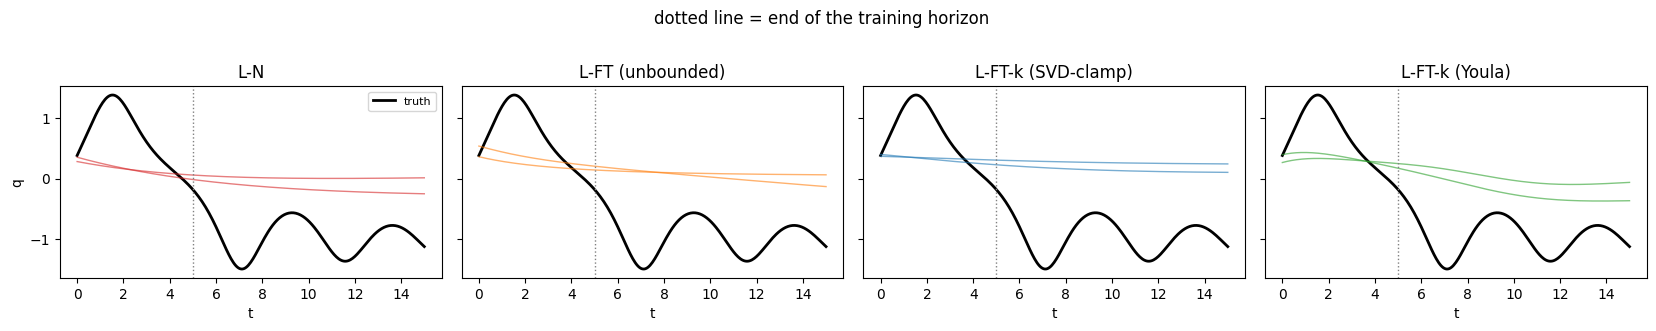

In [10]:
TRAJ = 0
fig, axes = plt.subplots(1, len(SLUGS), figsize=(4.2 * len(SLUGS), 3.2), sharey=True)
for ax, slug in zip(np.atleast_1d(axes), SLUGS):
    ax.plot(tline_e, Yva_np[TRAJ], 'k', lw=2, label='truth')
    for si in range(len(SEEDS)):
        ax.plot(tline_e, ROLL[slug]['yhat'][si, TRAJ], color=COLOR[slug], alpha=.6, lw=1)
    ax.axvline(T_train, ls=':', c='gray', lw=1)
    ax.set_title(LABEL[slug]); ax.set_xlabel('t')
np.atleast_1d(axes)[0].set_ylabel('q'); np.atleast_1d(axes)[0].legend(fontsize=8)
fig.suptitle('dotted line = end of the training horizon', y=1.02)
fig.tight_layout(); plt.show()

## D4 — per-horizon reconstruction MSE

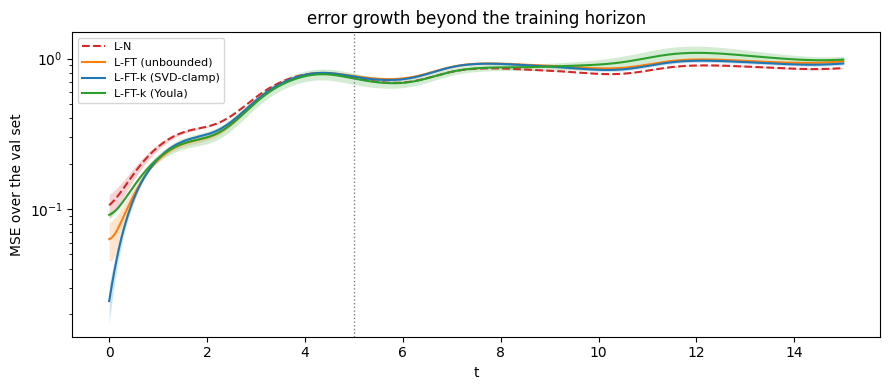

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
for slug in SLUGS:
    mse_t = np.nanmean((ROLL[slug]['yhat'] - Yva_np[None]) ** 2, axis=1)
    mean, std = np.nanmean(mse_t, 0), np.nanstd(mse_t, 0)
    ax.plot(tline_e, mean, label=LABEL[slug], **style(slug))
    ax.fill_between(tline_e, mean - std, mean + std, color=COLOR[slug], alpha=.2, lw=0)
ax.axvline(T_train, ls=':', c='gray', lw=1)
ax.set_yscale('log'); ax.set_xlabel('t'); ax.set_ylabel('MSE over the val set')
ax.set_title('error growth beyond the training horizon'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## D5 — implicit recovery of the hidden coordinate

Can a *linear* readout of the latent state recover `q_dot`, which no model ever saw?

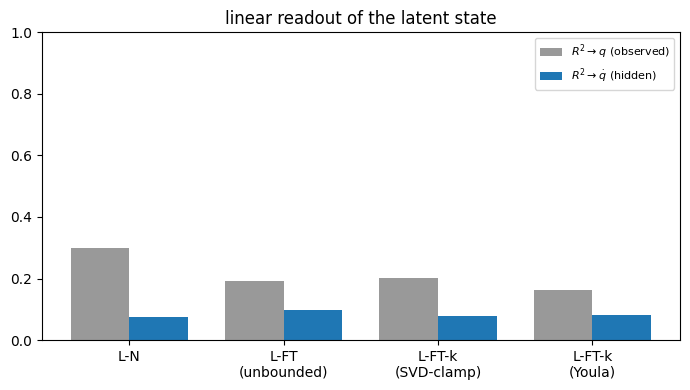

L-N                      R2->q 0.301   R2->qdot 0.074
L-FT (unbounded)         R2->q 0.191   R2->qdot 0.098
L-FT-k (SVD-clamp)       R2->q 0.201   R2->qdot 0.078
L-FT-k (Youla)           R2->q 0.163   R2->qdot 0.081

NOTE: at a QUICK-preset run these are uninformative -- R2->q itself is still
low, so the models have not learned even the observed coordinate yet.


In [12]:
Xva  = val.Xfull
Q    = Xva[..., 0].numpy().reshape(-1)
Qdot = Xva[..., 1].numpy().reshape(-1)
perm = np.random.default_rng(7).permutation(Q.shape[0]); half = len(perm) // 2
fit_idx, eval_idx = perm[:half], perm[half:]

rows = []
for slug in SLUGS:
    r2q, r2qd = [], []
    for si in range(len(SEEDS)):
        Z = ROLL[slug]['z'][si].reshape(-1, budget.m)
        ok = np.isfinite(Z).all(1)
        if ok.sum() < 100:
            continue
        f = fit_idx[ok[fit_idx]]; e = eval_idx[ok[eval_idx]]
        r2q.append(linear_recovery_r2(Z, Q, f, e))
        r2qd.append(linear_recovery_r2(Z, Qdot, f, e))
    rows.append((slug, np.mean(r2q) if r2q else np.nan, np.mean(r2qd) if r2qd else np.nan))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(rows)); w = 0.38
ax.bar(x - w/2, [r[1] for r in rows], w, label=r'$R^2 \to q$ (observed)', color='0.6')
ax.bar(x + w/2, [r[2] for r in rows], w, label=r'$R^2 \to \dot q$ (hidden)', color='C0')
ax.set_xticks(x); ax.set_xticklabels([LABEL[r[0]].replace(' ', '\n') for r in rows])
ax.set_ylim(0, 1); ax.legend(fontsize=8)
ax.set_title('linear readout of the latent state'); fig.tight_layout(); plt.show()

for slug, a, b in rows:
    print(f'{LABEL[slug]:24s} R2->q {a:.3f}   R2->qdot {b:.3f}')
print('\nNOTE: at a QUICK-preset run these are uninformative -- R2->q itself is still')
print('low, so the models have not learned even the observed coordinate yet.')

## D6 / D7 — phase portrait and latent-space geometry

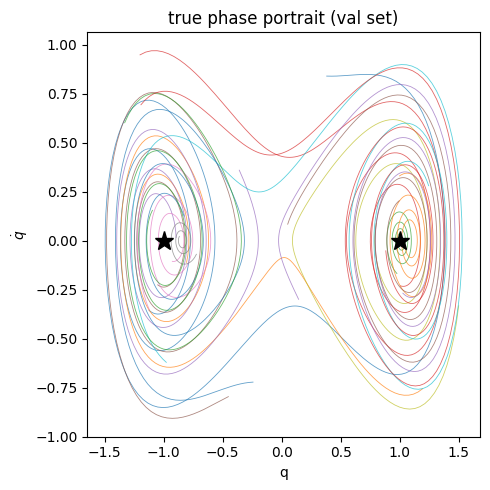

In [13]:
Xva_np = val.Xfull.numpy()
fig, ax = plt.subplots(figsize=(5, 5))
for i in range(min(16, Xva_np.shape[0])):
    ax.plot(Xva_np[i, :, 0], Xva_np[i, :, 1], lw=0.6, alpha=0.7)
for label, eq in sinks(0.0).items():
    ax.plot(*eq, 'k*', ms=14)
ax.set_xlabel('q'); ax.set_ylabel(r'$\dot q$'); ax.set_title('true phase portrait (val set)')
fig.tight_layout(); plt.show()

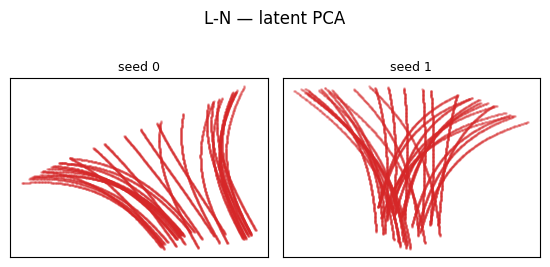

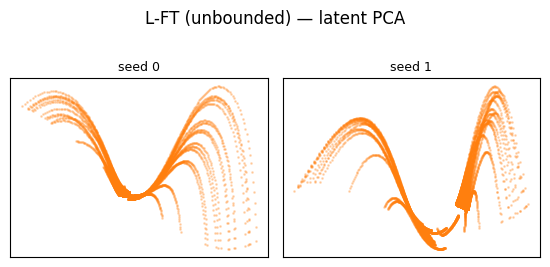

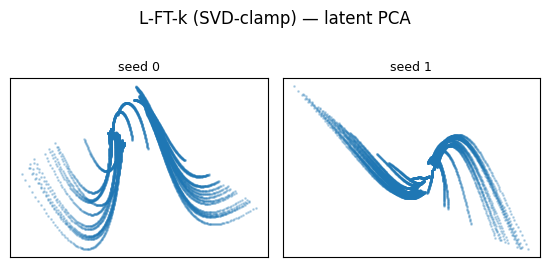

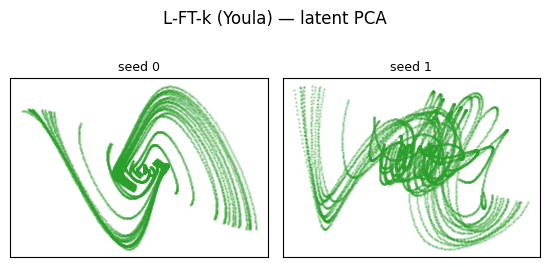

In [14]:
for slug in SLUGS:
    fig, axes = seed_grid(len(SEEDS), ncols=5, panel=(2.8, 2.6))
    for si, seed in enumerate(SEEDS):
        ax = axes[si]
        Z = ROLL[slug]['z'][si].reshape(-1, budget.m)
        ok = np.isfinite(Z).all(1)
        if ok.sum() > 10:
            proj, _ = pca_2d(Z[ok])          # pca_2d returns (proj, basis)
            ax.scatter(proj[:, 0], proj[:, 1], s=1, alpha=.25, color=COLOR[slug])
        ax.set_title(f'seed {seed}', fontsize=9); ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f'{LABEL[slug]} — latent PCA', y=1.01)
    fig.tight_layout(); plt.show()

## D8 — spectrum in the complex plane

/home/ike/Documents/github/FTNODE/.venv/lib/python3.10/site-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


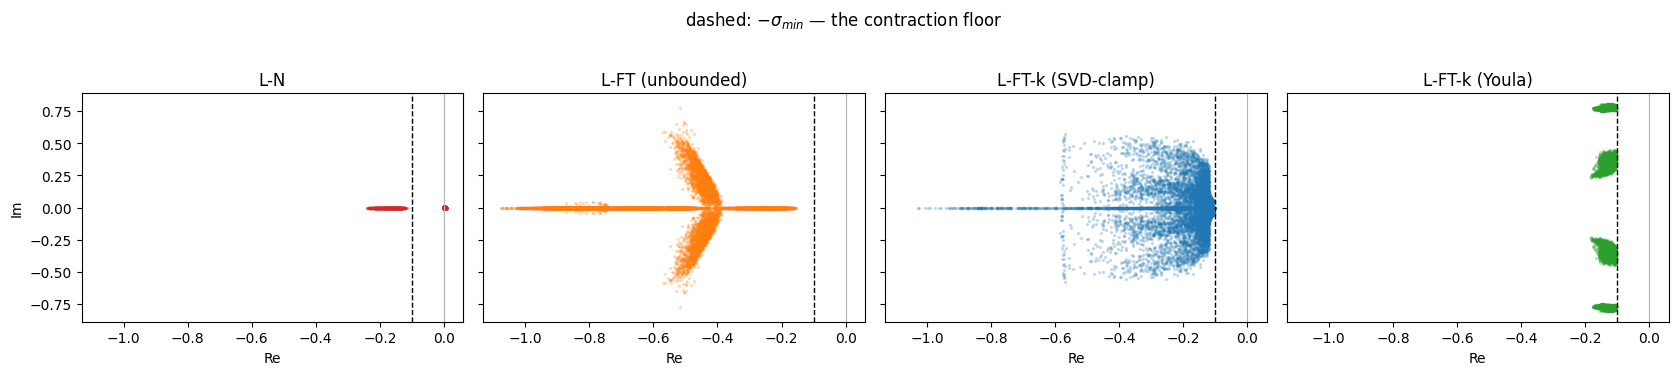

In [15]:
Ubox = torch.zeros(Zbox.shape[0], device=device)
fig, axes = plt.subplots(1, len(SLUGS), figsize=(4.2 * len(SLUGS), 3.6), sharex=True, sharey=True)
for ax, slug in zip(np.atleast_1d(axes), SLUGS):
    dyn = next(m.dynamics.eval() for m in models[slug] if m is not None)
    # LatentNODE exposes no A(z), so its spectrum comes from the field Jacobian.
    ev = (eigvals_A(dyn, Zbox, budget.m) if hasattr(dyn, 'A')
          else eig_field_jac(dyn, Zbox[:1000], Ubox[:1000], budget.m))
    ax.scatter(ev.real.ravel(), ev.imag.ravel(), s=2, alpha=.2, color=COLOR[slug])
    ax.axvline(-budget.sigma_min, ls='--', c='k', lw=1)
    ax.axvline(0, c='0.7', lw=.8)
    ax.set_title(LABEL[slug]); ax.set_xlabel('Re')
np.atleast_1d(axes)[0].set_ylabel('Im')
fig.suptitle(r'dashed: $-\sigma_{min}$ — the contraction floor', y=1.03)
fig.tight_layout(); plt.show()

## D9 — decoded equilibrium map vs the true pitchfork

Equilibrium-map bound check, |g|_inf <= R_g = 2.00:
  L-FT (unbounded)         max |g|_inf = 1.307   ok=True
  L-FT-k (SVD-clamp)       max |g|_inf = 1.145   ok=True
  L-FT-k (Youla)           max |g|_inf = 1.266   ok=True


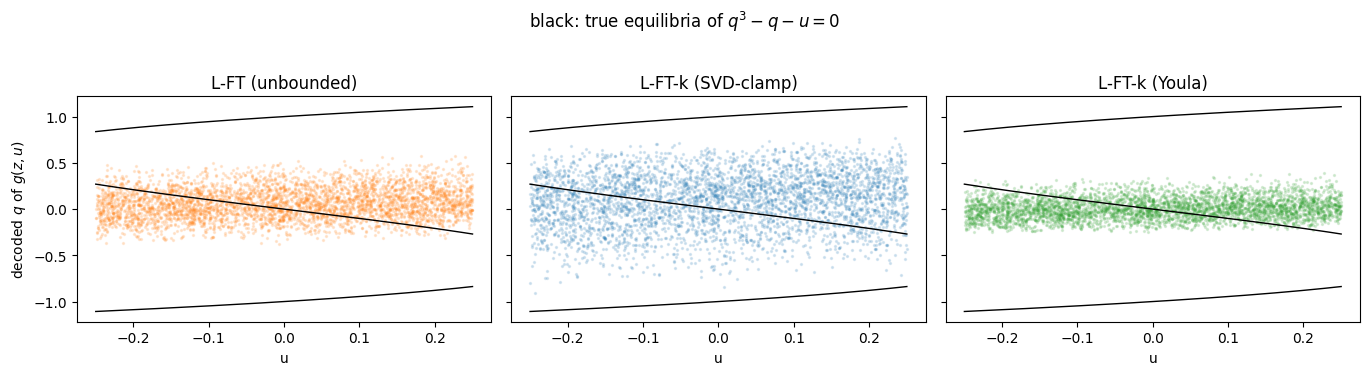

In [16]:
gen   = torch.Generator().manual_seed(0)
R_g   = model_cfg.equilibrium.R_g
Z_box = ((2 * torch.rand(4000, budget.m, generator=gen) - 1) * R_g).to(device)
U_box = ((2 * torch.rand(4000, generator=gen) - 1) * spec.data_train.u_range).to(device)

print(f'Equilibrium-map bound check, |g|_inf <= R_g = {R_g:.2f}:')
for slug in FT_SLUGS:
    mx = np.array([g_image(m.dynamics, Z_box, U_box).abs().max().item()
                   for m in models[slug] if m is not None])
    print(f'  {LABEL[slug]:24s} max |g|_inf = {mx.max():.3f}   ok={bool((mx <= R_g + 1e-4).all())}')

u_grid = np.linspace(-spec.data_train.u_range, spec.data_train.u_range, 200)
branches = np.array([[e[0] for e in equilibria(u)] for u in u_grid])

fig, axes = plt.subplots(1, len(FT_SLUGS), figsize=(4.6 * len(FT_SLUGS), 3.6),
                         sharey=True, squeeze=False)
for ax, slug in zip(axes[0], FT_SLUGS):
    mdl = next(m for m in models[slug] if m is not None)
    with torch.no_grad():
        G = g_image(mdl.dynamics, Z_box, U_box)
        q_hat = mdl.decode(G).cpu().numpy()
    ax.scatter(U_box.cpu().numpy(), q_hat, s=2, alpha=.15, color=COLOR[slug])
    for b in branches.T:
        ax.plot(u_grid, b, 'k', lw=1)
    ax.set_title(LABEL[slug]); ax.set_xlabel('u')
axes[0][0].set_ylabel(r'decoded $q$ of $g(z,u)$')
fig.suptitle('black: true equilibria of $q^3 - q - u = 0$', y=1.03)
fig.tight_layout(); plt.show()

## Takeaway

The κ bound is **structural**: `K2/K3` show it holding on trained weights for the
clamp and Youla operators at every sampled `z`, and `K4` shows `‖K‖₂` inside its
`c_K` budget — neither is a penalty that training could trade away. The unbounded
variant is the control: same contraction floor, no cap, and `κ` free to grow.

To re-plot any of this against a different run, change `RUN` in the first cell.
Nothing here trains, so iterating on a figure costs seconds.